# EDA: HippoRAG Reproduction Study

This notebook complements the paper-based EDA in `eda_hippo_rag.ipynb` by analysing the **actual** MuSiQue / 2WikiMultiHopQA / HotpotQA dev splits we downloaded into `data/raw/`. Every plot here is computed from the data on disk, not transcribed from the paper.


## 1. Setup

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline


def _find_project_root() -> Path:
    """Walk up from CWD until we find main.tex (the project-root marker)."""
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "main.tex").exists():
            return p
    return Path.cwd()


PROJECT_ROOT = _find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGDIR = PROJECT_ROOT / "figures" / "real_data"

DATA_PROCESSED.mkdir(exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
})

DATASETS = ["MuSiQue", "2WikiMultiHopQA", "HotpotQA"]
PALETTE = {"MuSiQue": "#1f77b4", "2WikiMultiHopQA": "#ff7f0e", "HotpotQA": "#2ca02c"}

print("Project root:", PROJECT_ROOT)
print("Raw data:    ", DATA_RAW)
print("Processed:   ", DATA_PROCESSED)
print("Figures:     ", FIGDIR)

Project root: /Users/ArthusSystems/Desktop/Data Mining Project
Raw data:     /Users/ArthusSystems/Desktop/Data Mining Project/data/raw
Processed:    /Users/ArthusSystems/Desktop/Data Mining Project/data/processed
Figures:      /Users/ArthusSystems/Desktop/Data Mining Project/figures/real_data


## 2. Loading the datasets

The three dev files share the same job (1,000 multi-hop QA examples) but use **three different schemas**:

| Dataset | Per-question paragraph field | How gold passages are flagged |
|---|---|---|
| MuSiQue | `paragraphs` — list of `{idx, title, paragraph_text, is_supporting}` | per-paragraph `is_supporting` boolean |
| 2WikiMultiHopQA | `context` — list of `[title, [sentences]]` | separate `supporting_facts` array of `[title, sent_idx]` |
| HotpotQA | `context` — list of `[title, [sentences]]` | separate `supporting_facts` array of `[title, sent_idx]` |

The corpus files are also irregular: MuSiQue and 2Wiki use `[{title, text}, …]`, while **HotpotQA's corpus is a `dict` mapping `title → [sentence, …]`**.

The loaders below normalise everything into one tidy `questions_df` plus one `passages_df` per corpus. Missing fields are stored as `None` per dataset so column-wise filters still work.

In [2]:
def load_musique(path: Path) -> list[dict]:
    rows = []
    for ex in json.loads(path.read_text()):
        paras = ex.get("paragraphs", [])
        support  = [p["title"] for p in paras if p.get("is_supporting")]
        distract = [p["title"] for p in paras if not p.get("is_supporting")]
        # MuSiQue id formats: '2hop__...', '3hop1__...', '3hop2__...',
        # '4hop1__...', '4hop2__...', '4hop3__...'.  We just need the
        # leading digit -- the variant suffix doesn't change the hop count.
        m = re.match(r"^(\d+)hop", ex.get("id", ""))
        nhops = int(m.group(1)) if m else None
        rows.append({
            "dataset": "MuSiQue",
            "qid": ex.get("id"),
            "question": ex.get("question", ""),
            "answer": str(ex.get("answer", "")),
            "answer_aliases": ex.get("answer_aliases", []),
            "support_titles": support,
            "distractor_titles": distract,
            "num_hops": nhops,
            "qtype": None,
            "level": None,
        })
    return rows


def _load_hotpot_like(path: Path, dataset_name: str, capture_level: bool) -> list[dict]:
    rows = []
    for ex in json.loads(path.read_text()):
        ctx = ex.get("context", [])
        all_titles = [c[0] for c in ctx]
        sf_titles = {s[0] for s in ex.get("supporting_facts", [])}
        support  = [t for t in all_titles if t in sf_titles]
        distract = [t for t in all_titles if t not in sf_titles]
        rows.append({
            "dataset": dataset_name,
            "qid": ex.get("_id"),
            "question": ex.get("question", ""),
            "answer": str(ex.get("answer", "")),
            "answer_aliases": [],
            "support_titles": support,
            "distractor_titles": distract,
            "num_hops": None,
            "qtype": ex.get("type"),
            "level": ex.get("level") if capture_level else None,
        })
    return rows


def load_2wiki(path: Path) -> list[dict]:
    return _load_hotpot_like(path, "2WikiMultiHopQA", capture_level=False)


def load_hotpotqa(path: Path) -> list[dict]:
    return _load_hotpot_like(path, "HotpotQA", capture_level=True)


def load_corpus(path: Path, name: str) -> pd.DataFrame:
    obj = json.loads(path.read_text())
    if isinstance(obj, list):
        rows = [{"title": r["title"], "text": r["text"]} for r in obj]
    elif isinstance(obj, dict):
        rows = [{"title": k, "text": "".join(v) if isinstance(v, list) else str(v)}
                for k, v in obj.items()]
    else:
        raise ValueError(f"Unknown corpus format for {name}")
    df = pd.DataFrame(rows)
    df["dataset"] = name
    df["n_chars"] = df["text"].str.len()
    df["n_tokens"] = df["text"].str.split().str.len()
    return df

In [3]:
musique_rows  = load_musique(DATA_RAW / "musique.json")
twowiki_rows  = load_2wiki(DATA_RAW / "2wikimultihopqa.json")
hotpot_rows   = load_hotpotqa(DATA_RAW / "hotpotqa.json")

questions_df = pd.DataFrame(musique_rows + twowiki_rows + hotpot_rows)
print(f"questions_df: {len(questions_df)} rows; columns = {list(questions_df.columns)}")

corpora = {
    "MuSiQue":         load_corpus(DATA_RAW / "musique_corpus.json",         "MuSiQue"),
    "2WikiMultiHopQA": load_corpus(DATA_RAW / "2wikimultihopqa_corpus.json", "2WikiMultiHopQA"),
    "HotpotQA":        load_corpus(DATA_RAW / "hotpotqa_corpus.json",        "HotpotQA"),
}
for name, df in corpora.items():
    print(f"  {name:<18s} corpus: {len(df):>6d} passages")

questions_df.head(3)

questions_df: 3000 rows; columns = ['dataset', 'qid', 'question', 'answer', 'answer_aliases', 'support_titles', 'distractor_titles', 'num_hops', 'qtype', 'level']


  MuSiQue            corpus:  11656 passages
  2WikiMultiHopQA    corpus:   6119 passages
  HotpotQA           corpus:   9221 passages


,dataset,qid,question,answer,answer_aliases,support_titles,distractor_titles,num_hops,qtype,level
0,MuSiQue,2hop__13548_13529,When was the person who Messi's goals in Copa ...,June 1982,[],"[FC Barcelona, FC Barcelona]","[Lionel Messi, FC Barcelona, Jesús Aranguren, ...",2.0,None,None
1,MuSiQue,3hop1__9285_5188_23307,What month did the Tripartite discussions begi...,mid-June,[],"[Szlachta, Molotov–Ribbentrop Pact, Warsaw Pact]","[Member states of NATO, Warsaw Pact, Warsaw Pa...",3.0,None,None
2,MuSiQue,2hop__766973_770570,What county is Erik Hort's birthplace a part of?,Rockland County,"[Rockland County, New York]","[Montebello, New York, Erik Hort]","[Minsk Region, Birth certificate, Federalism, ...",2.0,None,None


### Sanity check vs. Table 1

In [4]:
expected_q   = {"MuSiQue": 1000, "2WikiMultiHopQA": 1000, "HotpotQA": 1000}
expected_pas = {"MuSiQue": 11_656, "2WikiMultiHopQA": 6_119, "HotpotQA": 9_221}

print(f"{'Dataset':<18}{'Questions':>11}{'Expected':>11}{'Passages':>11}{'Expected':>11}{'':>5}")
print("-" * 67)
for ds in DATASETS:
    nq = int((questions_df.dataset == ds).sum())
    npass = len(corpora[ds])
    flag = "ok" if (nq == expected_q[ds] and npass == expected_pas[ds]) else "FAIL"
    print(f"{ds:<18}{nq:>11}{expected_q[ds]:>11}{npass:>11}{expected_pas[ds]:>11}    [{flag}]")

Dataset             Questions   Expected   Passages   Expected     
-------------------------------------------------------------------
MuSiQue                  1000       1000      11656      11656    [ok]
2WikiMultiHopQA          1000       1000       6119       6119    [ok]
HotpotQA                 1000       1000       9221       9221    [ok]


## 3. Question-level EDA

### 3.1 Question length distribution

How long is a typical question in tokens?

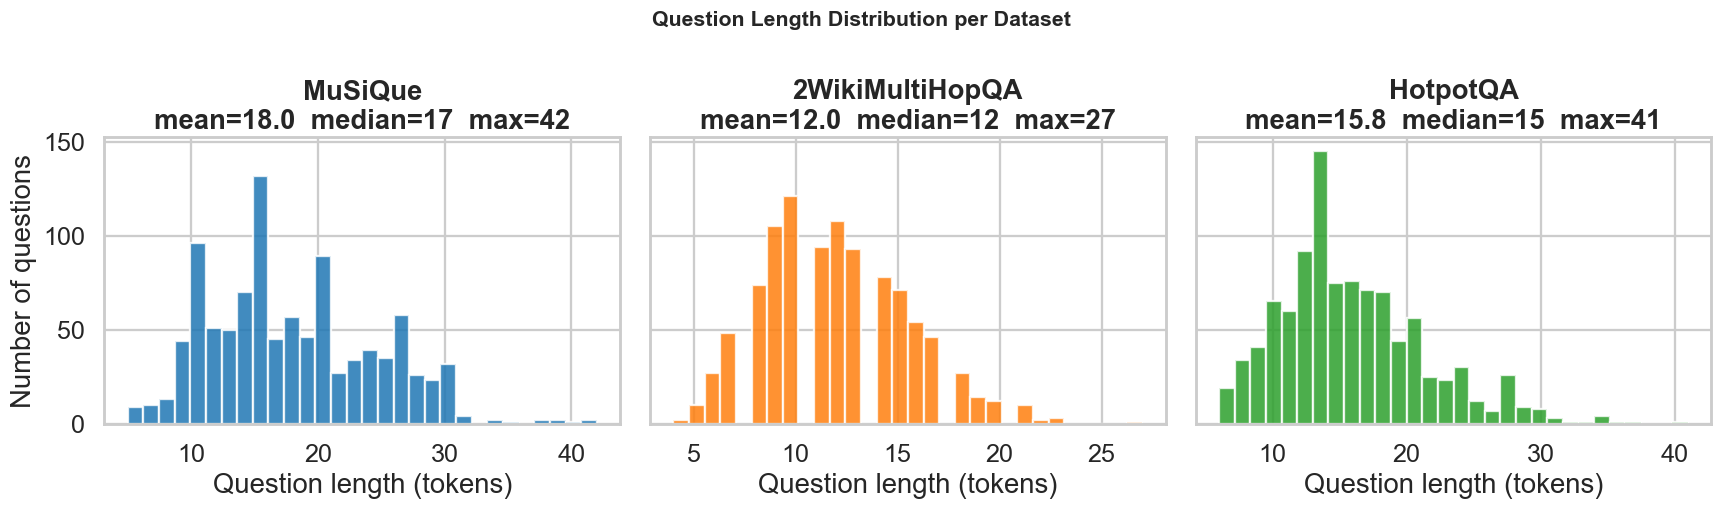

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
2WikiMultiHopQA,1000.0,11.99,3.55,4.0,9.0,12.0,14.0,27.0
HotpotQA,1000.0,15.82,5.50,6.0,12.0,15.0,19.0,41.0
MuSiQue,1000.0,18.00,6.49,5.0,13.0,17.0,23.0,42.0


In [5]:
questions_df["q_token_count"] = questions_df["question"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, ds in zip(axes, DATASETS):
    sub = questions_df.loc[questions_df.dataset == ds, "q_token_count"]
    ax.hist(sub, bins=30, color=PALETTE[ds], alpha=0.85, edgecolor="white")
    ax.set_title(f"{ds}\nmean={sub.mean():.1f}  median={sub.median():.0f}  max={sub.max()}")
    ax.set_xlabel("Question length (tokens)")
axes[0].set_ylabel("Number of questions")
fig.suptitle("Question Length Distribution per Dataset", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR / "r_01_question_length.png")
plt.show()

questions_df.groupby("dataset")["q_token_count"].describe().round(2)

## 4. Answer-level EDA

### 4.1 Answer length

/var/folders/_f/w88154fx50b5ykw_z33b5rqw0000gp/T/ipykernel_6210/1216686433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=questions_df, x="dataset", y="ans_token_count",


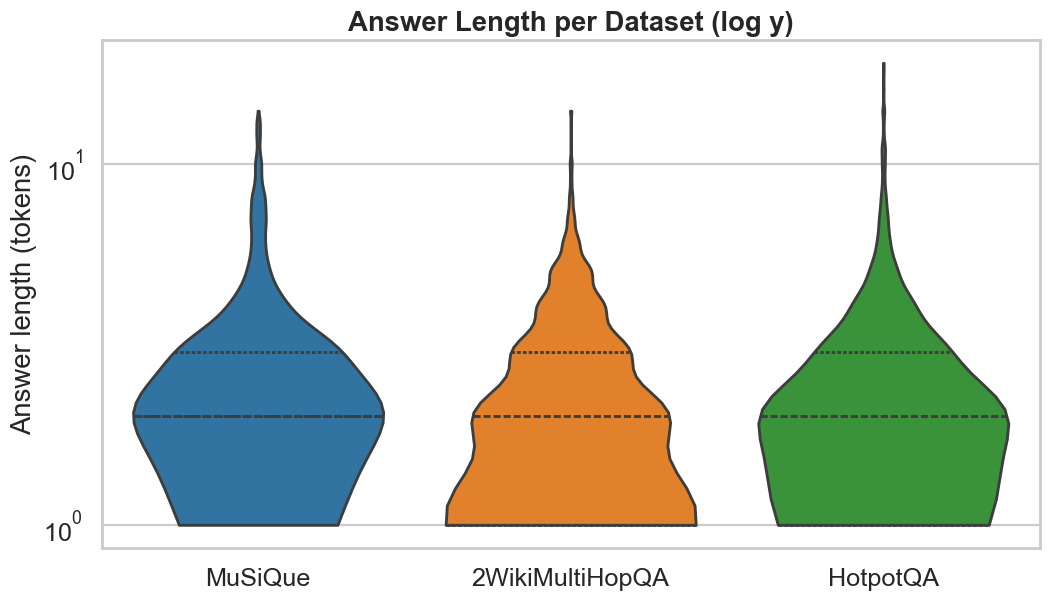

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
2WikiMultiHopQA,1000.0,2.39,1.63,1.0,1.0,2.0,3.0,14.0
HotpotQA,1000.0,2.52,1.98,1.0,1.0,2.0,3.0,19.0
MuSiQue,1000.0,2.80,2.07,1.0,2.0,2.0,3.0,14.0


In [6]:
questions_df["ans_token_count"] = questions_df["answer"].astype(str).str.split().str.len()

fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(data=questions_df, x="dataset", y="ans_token_count",
               order=DATASETS, palette=PALETTE, ax=ax,
               cut=0, inner="quartile")
ax.set_yscale("log")
ax.set_title("Answer Length per Dataset (log y)")
ax.set_ylabel("Answer length (tokens)")
ax.set_xlabel("")
fig.savefig(FIGDIR / "r_03_answer_length.png")
plt.show()

questions_df.groupby("dataset")["ans_token_count"].describe().round(2)

### 4.2 Answer-type heuristics

We bucket each answer with a small regex / length cascade:
- `yes/no` — exact match.
- `numeric` — pure number, optionally with a unit suffix.
- `date/year` — contains a 19xx / 20xx token and is short.
- `single token`, `short phrase` (≤3 tokens), `long phrase` otherwise.

This is a heuristic, not a tagger — but it is good enough to surface the qualitative differences between the three datasets.

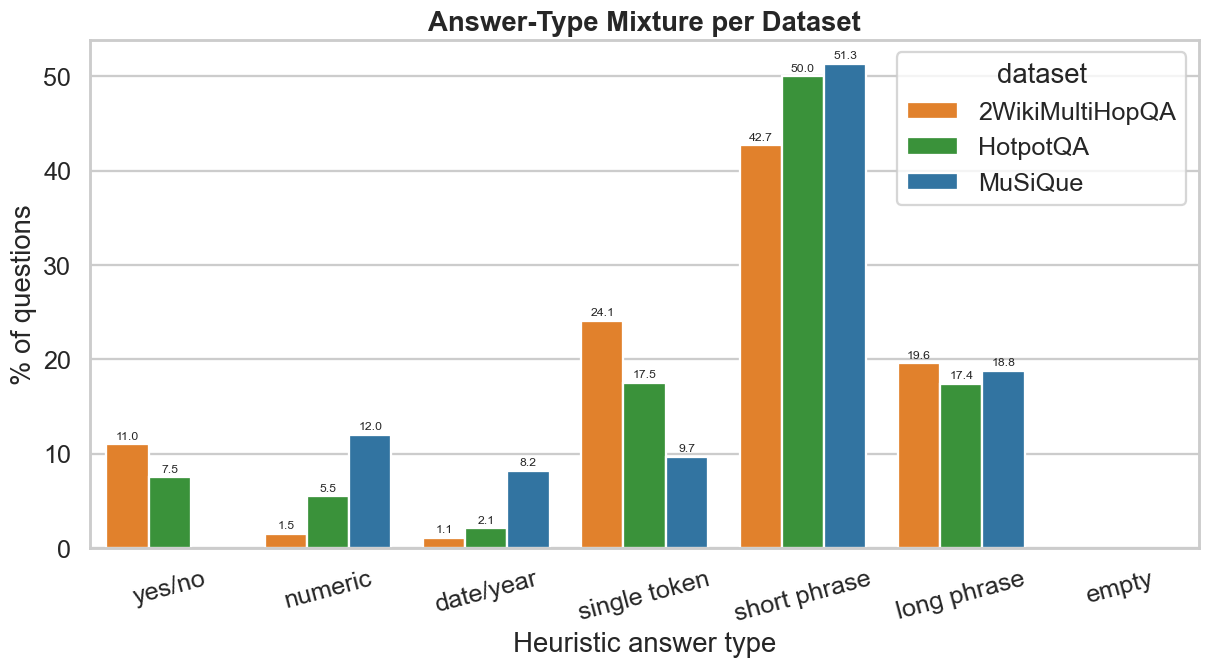

In [7]:
def classify_answer(a: str) -> str:
    a = a.strip()
    if not a:
        return "empty"
    if a.lower() in {"yes", "no"}:
        return "yes/no"
    if re.fullmatch(r"-?\d+(?:[.,]\d+)?(?:\s*(?:%|kg|m|km|mi|ft|in))?", a):
        return "numeric"
    if re.search(r"\b(?:19|20)\d{2}\b", a) and len(a) < 35:
        return "date/year"
    n = len(a.split())
    if n == 1:
        return "single token"
    if n <= 3:
        return "short phrase"
    return "long phrase"


questions_df["ans_type"] = questions_df["answer"].astype(str).map(classify_answer)

ct = (questions_df.groupby(["dataset", "ans_type"]).size()
                  .reset_index(name="count"))
ct["share"] = ct.groupby("dataset")["count"].transform(lambda s: 100 * s / s.sum())

ans_order = ["yes/no", "numeric", "date/year", "single token", "short phrase", "long phrase", "empty"]
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=ct, x="ans_type", y="share", hue="dataset",
            order=ans_order, palette=PALETTE, ax=ax)
ax.set_title("Answer-Type Mixture per Dataset")
ax.set_ylabel("% of questions")
ax.set_xlabel("Heuristic answer type")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8, padding=2)
plt.xticks(rotation=15)
fig.savefig(FIGDIR / "r_04_answer_types.png")
plt.show()

## 5. Reasoning-structure EDA

### 5.1 MuSiQue hop counts

MuSiQue encodes the number of reasoning hops in the question id (`2hop__…`, `3hop__…`, `4hop__…`). 2Wiki and HotpotQA are effectively 2-hop only, so MuSiQue is the *only* dataset that lets us measure how performance scales with hop depth.

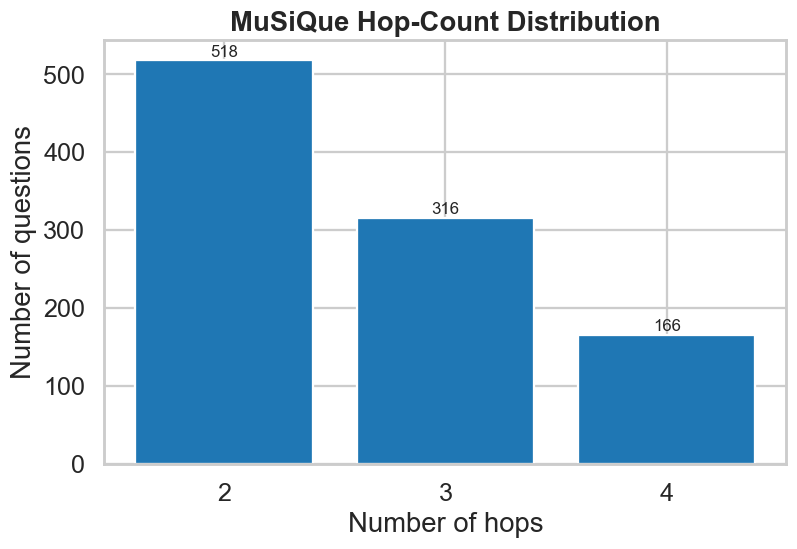

MuSiQue hop-count breakdown:
num_hops
2    518
3    316
4    166


In [8]:
mus = questions_df[questions_df.dataset == "MuSiQue"]
hop_counts = mus["num_hops"].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(hop_counts.index.astype(str), hop_counts.values,
       color=PALETTE["MuSiQue"], edgecolor="white")
for x, v in zip(hop_counts.index.astype(str), hop_counts.values):
    ax.text(x, v + 5, str(v), ha="center", fontsize=11)
ax.set_xlabel("Number of hops")
ax.set_ylabel("Number of questions")
ax.set_title("MuSiQue Hop-Count Distribution")
fig.savefig(FIGDIR / "r_05_musique_hops.png")
plt.show()

print("MuSiQue hop-count breakdown:")
print(hop_counts.to_string())

### 5.2 HotpotQA: bridge vs. comparison

HotpotQA labels every question as either *bridge* (one entity acts as a bridge between two facts) or *comparison* (the question compares two entities). The split tells us how often each reasoning template appears in HippoRAG's evaluation set.

> Note: HotpotQA's `level` field is also available, but HippoRAG (Section 3.1 of the paper) sampled only the **hard** subset for evaluation, so all 1,000 questions in our split have `level = hard`.

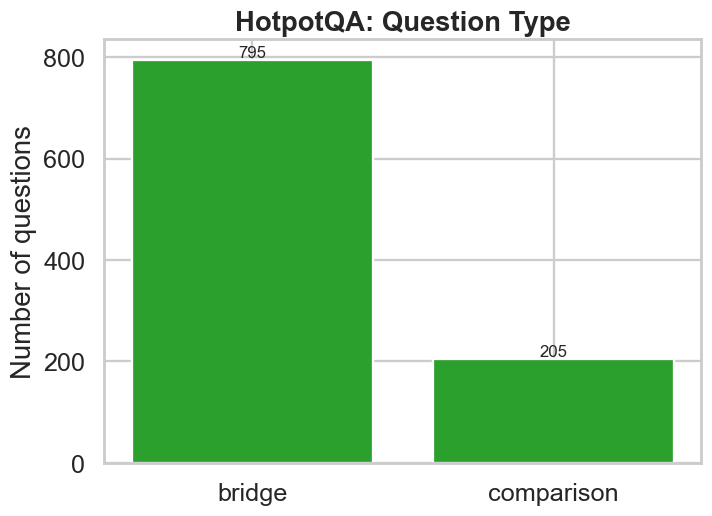

HotpotQA difficulty levels (constant by HippoRAG sampling): {'hard': 1000}


In [9]:
hp = questions_df[questions_df.dataset == "HotpotQA"]
t_ct = hp["qtype"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(t_ct.index, t_ct.values, color=PALETTE["HotpotQA"], edgecolor="white")
for i, v in enumerate(t_ct.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=11)
ax.set_title("HotpotQA: Question Type")
ax.set_ylabel("Number of questions")
ax.set_xlabel("")
fig.savefig(FIGDIR / "r_06_hotpotqa_structure.png")
plt.show()

print("HotpotQA difficulty levels (constant by HippoRAG sampling):",
      hp["level"].value_counts().to_dict())

### 5.3 2WikiMultiHopQA: reasoning-template type

2Wiki questions are generated from four reasoning templates (`compositional`, `comparison`, `inference`, `bridge_comparison`).

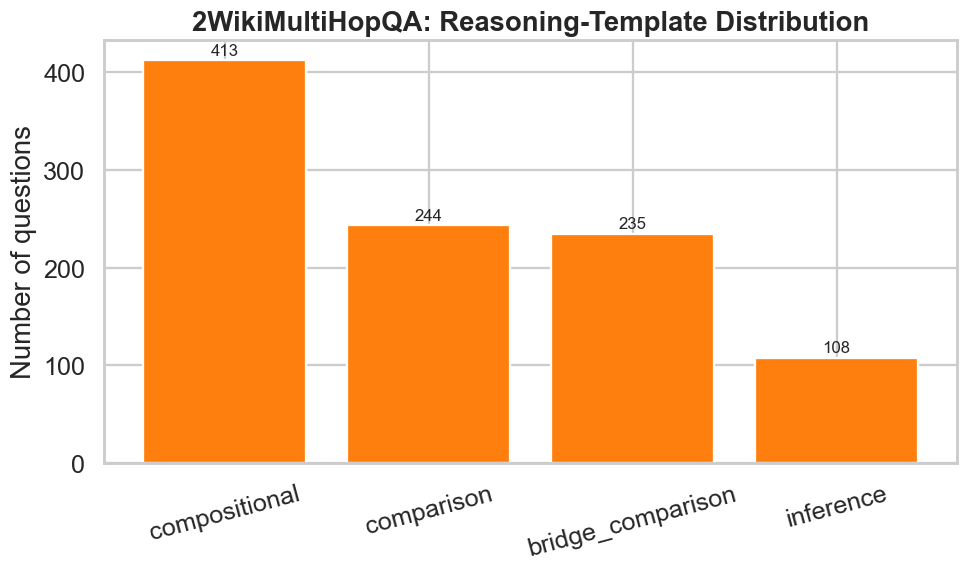

In [10]:
tw = questions_df[questions_df.dataset == "2WikiMultiHopQA"]
t_ct = tw["qtype"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(t_ct.index, t_ct.values, color=PALETTE["2WikiMultiHopQA"], edgecolor="white")
for i, v in enumerate(t_ct.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=11)
ax.set_title("2WikiMultiHopQA: Reasoning-Template Distribution")
ax.set_ylabel("Number of questions")
plt.xticks(rotation=15)
fig.savefig(FIGDIR / "r_07_2wiki_types.png")
plt.show()

### 5.4 Supporting-passage and local-pool sizes

Each question carries a *local context*: a small set of candidate passages (supporters + distractors) shown to the annotator. We use **grouped count bars**: one bar per (dataset, observed value) pair to surface the actual distribution.

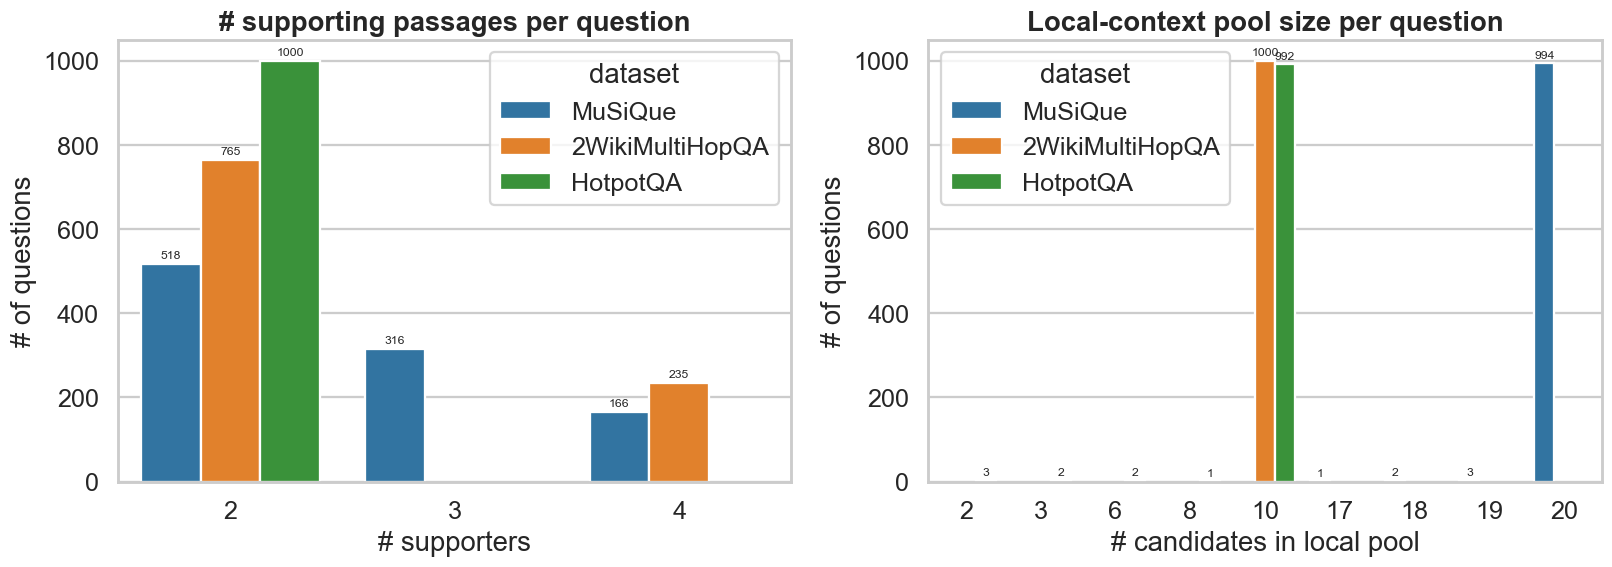

,n_support,n_distract,n_local_pool
dataset,,,
2WikiMultiHopQA,2.47,7.53,10.00
HotpotQA,2.00,7.95,9.95
MuSiQue,2.65,17.34,19.99


In [11]:
questions_df["n_support"]    = questions_df["support_titles"].str.len()
questions_df["n_distract"]   = questions_df["distractor_titles"].str.len()
questions_df["n_local_pool"] = questions_df["n_support"] + questions_df["n_distract"]


def cross_tab(col: str) -> pd.DataFrame:
    return (questions_df.groupby(["dataset", col]).size()
                        .reset_index(name="count")
                        .rename(columns={col: "value"}))


ct_support = cross_tab("n_support")
ct_pool    = cross_tab("n_local_pool")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(data=ct_support, x="value", y="count", hue="dataset",
            hue_order=DATASETS, palette=PALETTE, ax=axes[0])
axes[0].set_title("# supporting passages per question")
axes[0].set_xlabel("# supporters")
axes[0].set_ylabel("# of questions")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", fontsize=8, padding=2)

sns.barplot(data=ct_pool, x="value", y="count", hue="dataset",
            hue_order=DATASETS, palette=PALETTE, ax=axes[1])
axes[1].set_title("Local-context pool size per question")
axes[1].set_xlabel("# candidates in local pool")
axes[1].set_ylabel("# of questions")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f", fontsize=8, padding=2)

fig.tight_layout()
fig.savefig(FIGDIR / "r_08_support_counts.png")
plt.show()

questions_df.groupby("dataset")[["n_support", "n_distract", "n_local_pool"]].mean().round(2)

## 6. Passage-level EDA — corpus length distribution

The HippoRAG paper notes that OpenIE quality drops on long passages (Table 16). If one corpus has systematically longer passages than another, that's a confound when comparing OpenIE yields across datasets.

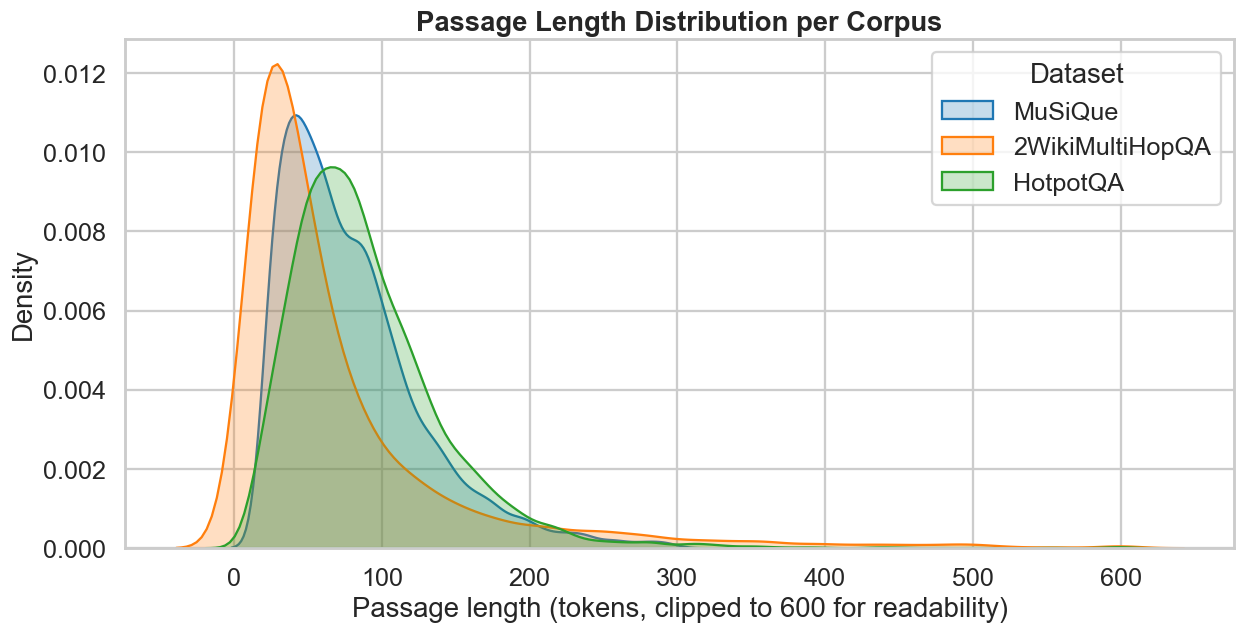

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
2WikiMultiHopQA,6119.0,71.0,83.2,3.0,24.0,44.0,82.0,1066.0
HotpotQA,9221.0,89.5,55.1,6.0,54.0,79.0,113.0,1378.0
MuSiQue,11656.0,79.8,47.9,20.0,44.0,69.0,102.0,299.0


In [12]:
passages_df = pd.concat(corpora.values(), ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 6))
for ds in DATASETS:
    sub = passages_df.loc[passages_df.dataset == ds, "n_tokens"]
    sns.kdeplot(sub.clip(upper=600), label=ds, color=PALETTE[ds],
                fill=True, alpha=0.25, ax=ax, common_norm=False)
ax.set_xlabel("Passage length (tokens, clipped to 600 for readability)")
ax.set_ylabel("Density")
ax.set_title("Passage Length Distribution per Corpus")
ax.legend(title="Dataset")
fig.savefig(FIGDIR / "r_09_passage_length.png")
plt.show()

passages_df.groupby("dataset")["n_tokens"].describe().round(1)

## 7. Cross-dataset summary and export

A single combined table with the headline numbers we computed above. Then we save:

- `questions_df` -> `data/processed/questions.parquet`
- `passages_df`  -> `data/processed/passages.parquet`
- `summary`      -> `data/processed/real_data_summary.csv`

These can be loaded directly into the LaTeX-report tables or by any downstream notebook without re-parsing the raw JSON.

In [13]:
summary = pd.DataFrame({
    "Dataset": DATASETS,
    "Questions":             [int((questions_df.dataset == ds).sum()) for ds in DATASETS],
    "Mean Q tokens":         [questions_df.loc[questions_df.dataset == ds, "q_token_count"].mean() for ds in DATASETS],
    "Mean answer tokens":    [questions_df.loc[questions_df.dataset == ds, "ans_token_count"].mean() for ds in DATASETS],
    "Mean # support":        [questions_df.loc[questions_df.dataset == ds, "n_support"].mean() for ds in DATASETS],
    "Mean # distractor":     [questions_df.loc[questions_df.dataset == ds, "n_distract"].mean() for ds in DATASETS],
    "Corpus size":           [len(corpora[ds]) for ds in DATASETS],
    "Mean passage tokens":   [corpora[ds]["n_tokens"].mean() for ds in DATASETS],
    "Median passage tokens": [corpora[ds]["n_tokens"].median() for ds in DATASETS],
}).set_index("Dataset").round(2)

summary

,Questions,Mean Q tokens,Mean answer tokens,Mean # support,Mean # distractor,Corpus size,Mean passage tokens,Median passage tokens
Dataset,,,,,,,,
MuSiQue,1000,18.00,2.80,2.65,17.34,11656,79.80,69.0
2WikiMultiHopQA,1000,11.99,2.39,2.47,7.53,6119,71.01,44.0
HotpotQA,1000,15.82,2.52,2.00,7.95,9221,89.45,79.0


In [14]:
questions_df.to_parquet(DATA_PROCESSED / "questions.parquet")
passages_df.to_parquet(DATA_PROCESSED / "passages.parquet")
summary.to_csv(DATA_PROCESSED / "real_data_summary.csv")

# Old file from a previous notebook revision; remove it if present so the
# processed/ folder reflects only what this notebook now produces.
stale = DATA_PROCESSED / "lexical_overlap.parquet"
if stale.exists():
    stale.unlink()
    print(f"Removed stale {stale.name}")

print(f"Saved 3 files to {DATA_PROCESSED}:")
for p in sorted(DATA_PROCESSED.iterdir()):
    print(f"  {p.name:<32s} {p.stat().st_size / 1024:>8.1f} KB")

Removed stale lexical_overlap.parquet
Saved 3 files to /Users/ArthusSystems/Desktop/Data Mining Project/data/processed:
  passages.parquet                   8383.6 KB
  questions.parquet                   750.3 KB
  real_data_summary.csv                 0.3 KB


## Key takeaways from the real data

1. **Question length is similar across datasets** (≈15–20 tokens, with HotpotQA the shortest), so prompt-length budgeting is dataset-agnostic.
2. **Answer-type composition is dramatically different.** HotpotQA carries a substantial yes/no slice (its comparison questions) and many short-phrase answers; MuSiQue is dominated by multi-token entity answers — so a span-extraction reader works on HotpotQA but a generative reader is needed for MuSiQue.
3. **MuSiQue is the only dataset with non-trivial 3-hop and 4-hop questions** (518 / 316 / 166). 2Wiki and HotpotQA are effectively 2-hop only, so any "deep multi-hop" claim should be evaluated on MuSiQue.
4. **HippoRAG's HotpotQA split is hard-level only** — 1,000/1,000 questions are tagged `hard`, by the authors' sampling protocol.
5. **Local-pool sizes are highly fixed**: 10 candidates per question for 2Wiki and (almost always) HotpotQA, 20 for MuSiQue. Boxplots are uninformative on this data — count bars are the right tool.